In [29]:
import pandas as pd

# =====================================================================
# 1. EINLESEN 
# =====================================================================
einstellungen = {'sep': ';', 'encoding': 'utf-8-sig'}

# Alle 3 Teile laden
t1 = pd.read_csv(r"C:\Users\muham\Desktop\relabel_Muhammed_translates.csv", **einstellungen)
t2 = pd.read_csv(r"C:\Users\muham\Desktop\Relabel_Maryam_translated.csv", **einstellungen)
t3 = pd.read_csv(r"C:\Users\muham\Desktop\Relabel_Janina_translated.csv", **einstellungen)

# Funktion, die unsichtbare Whitespaces aus den Headern der einzelnen Dateien radiert
def header_strippen(df):
    df.columns = df.columns.str.strip()
    return df

# Vor dem Zusammenführen bei allen drei Dateien die Spaltennamen säubern
t1 = header_strippen(t1)
t2 = header_strippen(t2)
t3 = header_strippen(t3)

# untereinander hängen
df_master = pd.concat([t1, t2, t3], ignore_index=True)

# Künstliche Leerzeilen löschen
df_master = df_master.dropna(how='all').reset_index(drop=True)

print("--- KONTROLLE NACH ZUSAMMENFÜHRUNG ---")
print(f"Dimensionen des Master-DF: {df_master.shape}")
print("Spaltennamen:", list(df_master.columns))

--- KONTROLLE NACH ZUSAMMENFÜHRUNG ---
Dimensionen des Master-DF: (92, 16)
Spaltennamen: ['qid', 'docid', 'title', 'abstract', 'title - English', 'abstract - English', 'language', 'has english partial (yes / no)', 'English where (top - bottom)', 'Clearly visible translated', 'new relevance', 'titel nonEN but abstractEN', 'has english parital (yes/no)', 'English where (top/bottom)', 'Clearly visible translated (yes/no)', 'llm_relevance']


Total analyzed: 92 documents
Changed: 64 documents (69.6%)
Unchanged: 28 documents (30.4%)


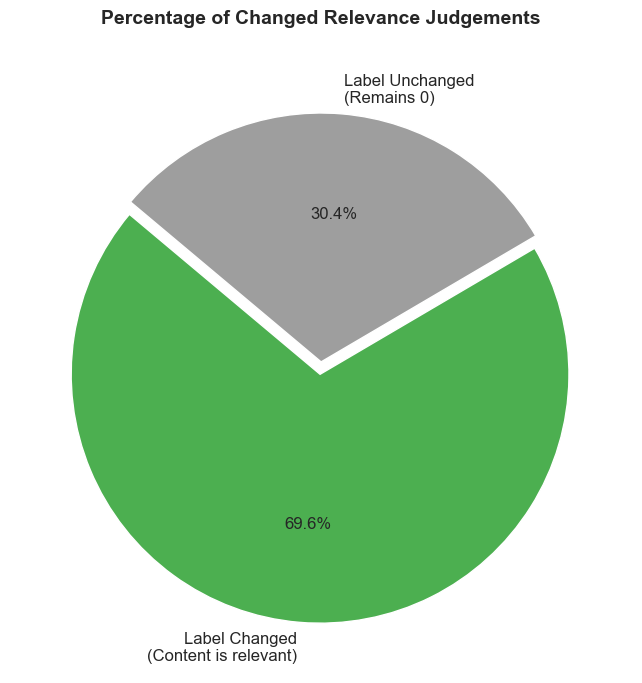

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Clean column names from whitespaces
df_master.columns = df_master.columns.str.strip()

# SAFETY CHECK: If the column exists multiple times, take the first one
if isinstance(df_master['new relevance'], pd.DataFrame):
    relevanz_spalte = df_master['new relevance'].iloc[:, 0]
else:
    relevanz_spalte = df_master['new relevance']

# Convert safely to integers
relevanz_werte = pd.to_numeric(relevanz_spalte, errors='coerce').fillna(0).astype(int)

# 1. Calculate changes (Anything that is NOT 0)
gesamt = len(df_master)
geaendert = (relevanz_werte != 0).sum()
unveraendert = gesamt - geaendert

prozent_geaendert = (geaendert / gesamt) * 100
prozent_unveraendert = 100 - prozent_geaendert

print(f"Total analyzed: {gesamt} documents")
print(f"Changed: {geaendert} documents ({prozent_geaendert:.1f}%)")
print(f"Unchanged: {unveraendert} documents ({prozent_unveraendert:.1f}%)")

# 2. Visualization as a Pie Chart
plt.figure(figsize=(7, 7))
sns.set_theme(style="whitegrid")

# labels for the pie slices
labels = ['Label Changed\n(Content is relevant)', 'Label Unchanged\n(Remains 0)']
sizes = [prozent_geaendert, prozent_unveraendert]
colors = ['#4CAF50', '#9E9E9E']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors, explode=(0.05, 0), textprops={'fontsize': 12})

# English Title
plt.title('Percentage of Changed Relevance Judgements', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

--- AKTUELLE VERTEILUNG DER RELEVANZWERTE ---
Relevanz-Label 0: 28 Dokumente
Relevanz-Label 1: 41 Dokumente
Relevanz-Label 2: 23 Dokumente


C:\Users\muham\AppData\Local\Temp\ipykernel_19536\2444991506.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=relevance_counts.index, y=relevance_counts.values, palette='Blues_d')


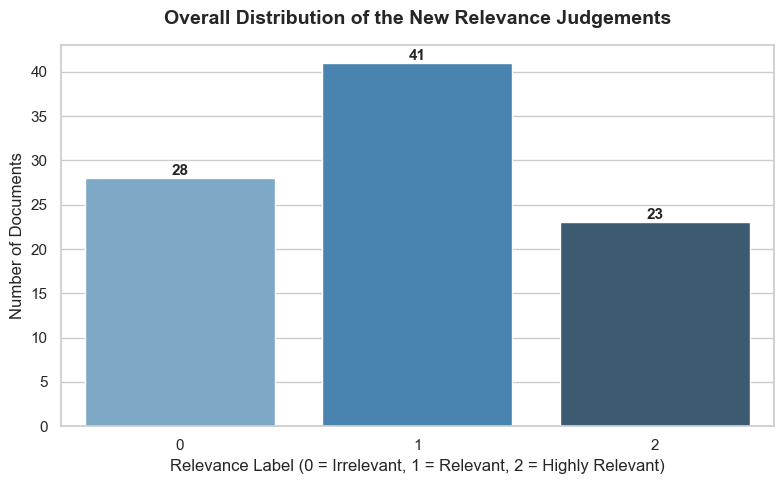

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Spalte in Zahlen umwandeln
sichere_relevanz = pd.to_numeric(df_master['new relevance'], errors='coerce')

# NaN-Werte sicher mit 0 auffüllen und alles als echte Ganzzahl (int) definieren
sichere_relevanz = sichere_relevanz.fillna(0).astype(int)

# 2. Häufigkeiten der neuen Relevanzwerte zählen und sortieren
relevance_counts = sichere_relevanz.value_counts().sort_index()

print("--- AKTUELLE VERTEILUNG DER RELEVANZWERTE ---")
for rel, count in relevance_counts.items():
    print(f"Relevanz-Label {rel}: {count} Dokumente")

# 3. Visualisierung als Balkendiagramm
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Balkendiagramm erstellen
ax = sns.barplot(x=relevance_counts.index, y=relevance_counts.values, palette='Blues_d')

# Labeling title and axes
plt.title('Overall Distribution of the New Relevance Judgements', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relevance Label (0 = Irrelevant, 1 = Relevant, 2 = Highly Relevant)', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)

# Die exakten Zahlen oben auf die Balken schreiben
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

--- AUSWERTUNG DER ENGLISCHEN TITEL ---
Dokumente mit bereits englischem Titel ('no'): 14 (15.2%)
Dokumente mit fremdsprachigem Titel ('yes'): 16 (17.4%)


C:\Users\muham\AppData\Local\Temp\ipykernel_19536\1128612096.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=titel_auswertung.index, y=titel_auswertung.values, palette='Set2')


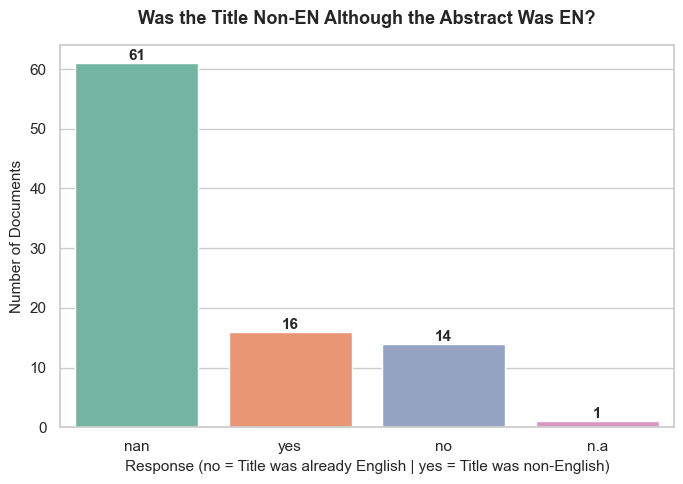

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Whitespaces bei den Werten in der Spalte entfernen und alles in Kleinbuchstaben umwandeln
df_master['titel nonEN but abstractEN'] = df_master['titel nonEN but abstractEN'].astype(str).str.strip().str.lower()

# Häufigkeiten zählen
titel_auswertung = df_master['titel nonEN but abstractEN'].value_counts()

# Berechnung für die Textausgabe
anzahl_englisch = titel_auswertung.get('no', 0)
anzahl_nicht_englisch = titel_auswertung.get('yes', 0)
gesamt_titel = anzahl_englisch + anzahl_nicht_englisch

print("--- AUSWERTUNG DER ENGLISCHEN TITEL ---")
if gesamt_titel > 0:
    prozent_englisch = (anzahl_englisch / len(df_master)) * 100
    print(f"Dokumente mit bereits englischem Titel ('no'): {anzahl_englisch} ({prozent_englisch:.1f}%)")
    print(f"Dokumente mit fremdsprachigem Titel ('yes'): {anzahl_nicht_englisch} ({(anzahl_nicht_englisch / len(df_master)) * 100:.1f}%)")
else:
    print("Spaltenwerte konnten nicht eindeutig als 'yes' oder 'no' identifiziert werden. Gefundene Werte:")
    print(titel_auswertung)

# 2. Visualisierung als Balkendiagramm
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# Die Verteilung plottem
ax = sns.barplot(x=titel_auswertung.index, y=titel_auswertung.values, palette='Set2')

# Labeling title and axes
plt.title('Was the Title Non-EN Although the Abstract Was EN?', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Response (no = Title was already English | yes = Title was non-English)', fontsize=11)
plt.ylabel('Number of Documents', fontsize=11)

# Die exakten Zahlen oben auf die Balken schreiben
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [39]:
import pandas as pd

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    display(df_master)  

,qid,docid,title,abstract,title - English,abstract - English,language,has english partial (yes / no),English where (top - bottom),Clearly visible translated,new relevance,titel nonEN but abstractEN,has english parital (yes/no),English where (top/bottom),Clearly visible translated (yes/no),llm_relevance
0,10c7ef19d812f4c1bacecc0ee54d30a8,292049822,Upaya Peningkatan Pengetahuan Remaja dalam Det...,Breast cancer (carcinoma mammae) or in English...,Efforts to Improve Adolescents’ Knowledge of E...,Breast cancer (carcinoma mammae) is a conditio...,Indonesisch,yes,top,yes,1,yes,NaN,NaN,NaN,NaN
1,10c7ef19d812f4c1bacecc0ee54d30a8,313546133,"Autoexamen de mama: previene, actúa y consulta...",El cáncer de mama es una enfermedad cuya princ...,"Breast Self-Exam: Prevent, Take Action, and Se...",Breast cancer is a disease characterized prima...,Spanisch,no,n.a,no,1,no,NaN,NaN,NaN,NaN
2,1bc4dce8577f8939ace5bf16d86b1829,297033218,मानसिक स्वास्थ्य एवं आत्महत्या - सामाजिक एवं म...,मानसिक स्वास्थ्य व्यक्ति के संपूर्ण जीवन का एक...,Mental Health and Suicide - A Social and Psych...,Mental health is a vital aspect of a person's ...,Hindi,no,n.a,no,2,no,NaN,NaN,NaN,NaN
3,253235b2573e803d3d7cb91bbe626407,275578591,PRESERVAÇÃO DO PATRIMÓNIO CULTURAL COMO ESTRAT...,"In the city of Pemba, cultural heritage repres...",PRESERVATION OF CULTURAL HERITAGE AS A STRATEG...,"In the city of Pemba, cultural heritage encomp...",Portugisisch,yes,top,yes,1,yes,NaN,NaN,NaN,NaN
4,253235b2573e803d3d7cb91bbe626407,308700944,Protegiendo la herencia cultural Chimbotana: d...,The revaluation of cultural heritage has been ...,Preserving Chimbote's Cultural Heritage: Chall...,The revitalization of cultural heritage has be...,Spanisch,yes,top,yes,1,yes,NaN,NaN,NaN,NaN
5,253235b2573e803d3d7cb91bbe626407,313476629,DIGITISATION OF THE PROCESS OF PRESERVATION AN...,У публікації досліджено діджиталізацію процесу...,DIGITISATION OF THE PROCESS OF PRESERVATION AN...,The preservation and safeguarding of intangibl...,Ukrainisch,yes,bottom,yes,1,no,NaN,NaN,NaN,NaN
6,253235b2573e803d3d7cb91bbe626407,314548712,Preserving Intangible Cultural Heritage: Revie...,يعد الحفاظ على التراث الثقافي غير المادي وصونه...,Preserving Intangible Cultural Heritage: Revie...,The preservation and safeguarding of intangibl...,Arabisch,no,n.a,no,1,yes,NaN,NaN,NaN,NaN
7,253235b2573e803d3d7cb91bbe626407,78340673,Cultural Heritage Digitization in Indonesia: A...,"Teknologi terkini, seperti fotografi digital, ...",Cultural Heritage Digitization in Indonesia: A...,"New technologies, such as digital photography,...",Indonesisch,yes,bottom,yes,0,yes,NaN,NaN,NaN,NaN
8,253235b2573e803d3d7cb91bbe626407,86360163,Cultural Heritage Digitization in Indonesia: A...,"Teknologi terkini, seperti fotografi digital, ...",Cultural Heritage Digitization in Indonesia: A...,"New technologies, such as digital photography,...",Indonesisch,yes,bottom,yes,0,yes,NaN,NaN,NaN,NaN
9,32b77e26bf1e161271a79b443af3b421,304389001,Los problemas de diseño de la política de tran...,La presente investigación tiene como objetivo ...,Design flaws in the sustainable urban public t...,The main objective of this research is to unde...,Spanisch,yes,bottom,yes,1,yes,NaN,NaN,NaN,NaN


In [41]:
# Alle einzigartigen Einträge aus der Sprach-Spalte anzeigen lassen
unbereinigte_sprachen = df_master['language'].astype(str).str.strip().value_counts()

print("--- GEFUNDENE SPRACHEINTRÄGE (UNBEREINIGT) ---")
print(unbereinigte_sprachen)

--- GEFUNDENE SPRACHEINTRÄGE (UNBEREINIGT) ---
language
indonesian             13
Spanisch               12
Spanish                 9
Indonesisch             8
spanish                 6
slovak                  5
Portugisisch            4
Portuguese              4
Ukranian                3
Indonesian              2
Russian                 2
Finish                  2
Basque                  2
Croatian                2
polish                  2
Hindi                   2
indonesian/ arabic      1
hindi                   1
catalan                 1
swedish                 1
French                  1
Italian                 1
Japanisch               1
Indonesian  /Arabic     1
Malayalam               1
Kroatisch               1
Czech                   1
Arabisch                1
Ukrainisch              1
thai                    1
Name: count, dtype: int64


--- BEREINIGTE SPRACHVERTEILUNG (ENGLISCHE BEZEICHNUNGEN) ---
language_clean_en
Spanish                27
Indonesian             23
Portuguese              8
Slovak                  5
Ukrainian               4
Hindi                   3
Croatian                3
Finnish                 2
Basque                  2
Indonesian / Arabic     2
Polish                  2
Russian                 2
Swedish                 1
Japanese                1
Thai                    1
Catalan                 1
French                  1
Italian                 1
Malayalam               1
Czech                   1
Arabic                  1
Name: count, dtype: int64


C:\Users\muham\AppData\Local\Temp\ipykernel_19536\1847128431.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sprachen_verteilung_en.values, y=sprachen_verteilung_en.index, palette='viridis')


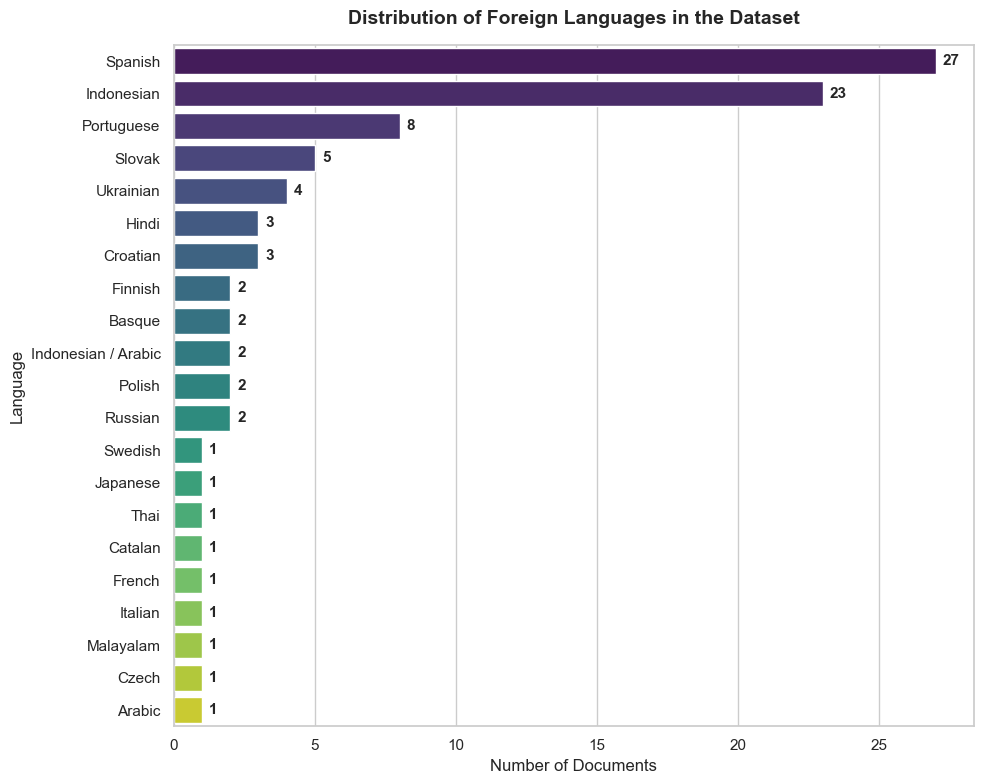

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Das Wörterbuch zur Vereinheitlichung auf ENGLISCH definieren
sprach_mapping_en = {
    # Indonesian
    'indonesian': 'Indonesian', 'indonesisch': 'Indonesian', 'indonesian ': 'Indonesian', 
    
    # Spanish
    'spanisch': 'Spanish', 'spanish': 'Spanish', 
    
    # Portuguese
    'portugisisch': 'Portuguese', 'portuguese': 'Portuguese',
    
    # Slovakian
    'slovak': 'Slovak',
    
    # Ukrainian
    'ukranian': 'Ukrainian', 'ukrainisch': 'Ukrainian',
    
    # Russian
    'russian': 'Russian',
    
    # Finnish
    'finish': 'Finnish',
    
    # Basque
    'basque': 'Basque',
    
    # Croatian
    'croatian': 'Croatian', 'kroatisch': 'Croatian',
    
    # Polish
    'polish': 'Polish',
    
    # Hindi
    'hindi': 'Hindi',
    
    # Catalan
    'catalan': 'Catalan',
    
    # Swedish
    'swedish': 'Swedish',
    
    # French
    'french': 'French',
    
    # Italian
    'italian': 'Italian',
    
    # Japanese
    'japanisch': 'Japanese',
    
    # Czech
    'czech': 'Czech',
    
    # Arabic
    'arabisch': 'Arabic',
    
    # Thai
    'thai': 'Thai',
    
    # Malayalam
    'malayalam': 'Malayalam',
    
    # Kombinierte Sprachen
    'indonesian/ arabic': 'Indonesian / Arabic',
    'indonesian  /arabic': 'Indonesian / Arabic'
}

# Spalte in String umwandeln, Leerzeichen außen entfernen und vereinheitlichen
df_master['language_clean_en'] = df_master['language'].astype(str).str.strip().str.lower()

# Fehlerhafte Schreibweisen überschreiben (wir verzichten auf das störende .capitalize())
df_master['language_clean_en'] = df_master['language_clean_en'].map(sprach_mapping_en).fillna(df_master['language_clean_en'])

# Häufigkeiten der bereinigten englischen Begriffe zählen
sprachen_verteilung_en = df_master['language_clean_en'].value_counts()

print("--- BEREINIGTE SPRACHVERTEILUNG (ENGLISCHE BEZEICHNUNGEN) ---")
print(sprachen_verteilung_en)


# =====================================================================
# 2. VISUALISIERUNG ALS HORIZONTALES BALKENDIAGRAMM
# =====================================================================
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Horizontales Balkendiagramm erzeugen
ax = sns.barplot(x=sprachen_verteilung_en.values, y=sprachen_verteilung_en.index, palette='viridis')

# Titel und Achsen beschriften (Beschriftung Deutsch, Kategorien Englisch)
plt.title('Distribution of Foreign Languages in the Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Documents', fontsize=12)
plt.ylabel('Language', fontsize=12)

# Die exakten Zahlen rechts an die Balken schreiben
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', 
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()